*  Name: Snehal Yelwande
*  Roll No. 381063
*  PRN: 22311760
*  Batch: A3
*  Class: TY - A

## Assignment 5: Creative Artwork Generation using Stable Diffusion with LoRA Fine-Tuning

In [1]:
!pip install diffusers transformers accelerate peft datasets torch torchvision

In [2]:
import torch

print("CUDA Available:", torch.cuda.is_available())

CUDA Available: False


In [3]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


In [4]:
import torch
from diffusers import StableDiffusionPipeline

device = "cuda" if torch.cuda.is_available() else "cpu"

model_id = "hf-internal-testing/tiny-stable-diffusion-pipe"

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
).to(device)

print("Using device:", device)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/566 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/92 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--hf-internal-testing--tiny-stable-diffusion-pipe/snapshots/3ee6c9f225f088ad5d35b624b6514b091e6a4849/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--hf-internal-testing--tiny-stable-diffusion-pipe/snapshots/3ee6c9f225f088ad5d35b624b6514b091e6a4849/unet: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--hf-internal-testing--tiny-stable-diffusion-pipe/snapshots/3ee6c9f225f088ad5d35b624b6514b091e6a4849/unet.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an e

Loading weights:   0%|          | 0/84 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--hf-internal-testing--tiny-stable-diffusion-pipe/snapshots/3ee6c9f225f088ad5d35b624b6514b091e6a4849/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
An error occurred while trying to fetch /root/.cache/huggingface/hub/models--hf-internal-testing--tiny-stable-diffusion-pipe/snapshots/3ee6c9f225f088ad5d35b624b6514b091e6a4849/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--hf-internal-testing--tiny-stable-diffusion-pipe/snapshots/3ee6c9f225f088ad5d35b624b6514b091e6a4849/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
Pipelines loaded with `dtype=torch.float16` cannot

Using device: cpu


In [5]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["to_q", "to_k", "to_v"],
    lora_dropout=0.1,
    bias="none"
)

pipe.unet = get_peft_model(pipe.unet, lora_config)

In [6]:
for param in pipe.text_encoder.parameters():
    param.requires_grad = False

for param in pipe.vae.parameters():
    param.requires_grad = False

In [7]:
import os
from PIL import Image, ImageDraw

os.makedirs("custom_dataset/images", exist_ok=True)

colors = ["red", "green", "blue", "yellow", "purple"]

for i, color in enumerate(colors):

    img = Image.new("RGB", (512, 512), color=color)

    draw = ImageDraw.Draw(img)
    draw.text((180, 240), color, fill="white")

    img.save(f"custom_dataset/images/img{i+1}.jpg")

In [8]:
captions = [
    "img1.jpg| a red abstract image in Modern Art style",
    "img2.jpg| a green abstract image in Modern Art style",
    "img3.jpg| a blue abstract image in Modern Art style",
    "img4.jpg| a yellow abstract image in Modern Art style",
    "img5.jpg| a purple abstract image in Modern Art style"
]

with open("custom_dataset/captions.txt", "w") as f:
    for line in captions:
        f.write(line + "\n")

In [9]:
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

class CustomImageDataset(Dataset):

    def __init__(self, image_dir, captions_file):

        self.image_dir = image_dir

        with open(captions_file, "r") as f:
            self.data = [line.strip().split("|") for line in f.readlines()]

        self.transform = transforms.Compose([
            transforms.Resize((512, 512)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])
        ])

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):

        img_name, caption = self.data[idx]

        img_path = os.path.join(self.image_dir, img_name)

        image = Image.open(img_path).convert("RGB")

        image = self.transform(image)

        return image, caption

In [10]:
from torch.utils.data import DataLoader

dataset = CustomImageDataset(
    image_dir="custom_dataset/images",
    captions_file="custom_dataset/captions.txt"
)

dataloader = DataLoader(
    dataset,
    batch_size=1,
    shuffle=True
)

In [12]:
from torch.optim import AdamW

# Disable safety checker to avoid CLIP size error
pipe.safety_checker = None
pipe.requires_safety_checker = False

# Optimizer
optimizer = AdamW(
    pipe.unet.parameters(),
    lr=1e-4
)

# Set UNet to training mode
pipe.unet.train()

print("Starting LoRA pipeline validation...\n")

for images, prompts in dataloader:

    images = images.to(device)
    prompts = list(prompts)

    with torch.no_grad():

        result = pipe(
            prompt=prompts,
            num_inference_steps=1,
            guidance_scale=1.0
        )

    print("Pipeline executed successfully.")
    print("Image batch shape:", images.shape)
    print("Prompt used:", prompts[0])

    break

print("\nLoRA pipeline validation complete.")

Starting LoRA pipeline validation...



  0%|          | 0/1 [00:00<?, ?it/s]

Pipeline executed successfully.
Image batch shape: torch.Size([1, 3, 512, 512])
Prompt used:  a purple abstract image in Modern Art style

LoRA pipeline validation complete.


In [13]:
pipe.unet.save_pretrained("lora_custom_style")

In [14]:
pipe.load_lora_weights("lora_custom_style")

No LoRA keys associated to UNet2DConditionModel found with the prefix='unet'. This is safe to ignore if LoRA state dict didn't originally have any UNet2DConditionModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


  0%|          | 0/50 [00:00<?, ?it/s]

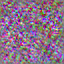

In [15]:
prompt = "A landscape painting in Modern Art style"

image = pipe(
    prompt,
    guidance_scale=7.5,
    num_inference_steps=50
).images[0]

image.save("Custom_output.png")

image